In [1]:
import pickle
import pathlib

import numpy as np
import pandas as pd
import scipy as sp

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from data_module import RosettaEnergiesDataModule
dm = RosettaEnergiesDataModule(parent="2D")
dm.setup(stage="test")

In [3]:
column_names = dm.column_names
relaxed_column_names = [x for x in column_names if x.startswith("r_")]
docking_column_names = [x for x in column_names if x not in relaxed_column_names]

In [4]:
model_stats_dir = pathlib.Path("../data/scratch/model_stats")

In [5]:
def model_embed_type(ncomp, freeze):
    embed_type = "One-hot"
    if ncomp > 0:
        embed_type = f"PCA dim {ncomp}"
    if freeze:
        embed_type += " : frozen" 
    else:
        embed_type += " : trainable"
    return embed_type

In [6]:
import warnings
warnings.filterwarnings("ignore", message = ".*An input array is constant.*")

def annotate_facet_with_correlations(predictions, values, ax=None, *args, **kwargs):
    pearson_r = sp.stats.pearsonr(predictions, values)
    spearman_r = sp.stats.spearmanr(predictions, values)
    if ax is None:
        ax = plt.gca()
    ax.text(0.05, 0.8, f"{pearson_r[0]:.2f} : pearson_r\n"
                   f"{spearman_r[0]:.2f}: spearman_r", 
        horizontalalignment='left',
        bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5),
        transform=ax.transAxes)
    
def plot_columns(column_names_to_plot, all_columns_names, predictions, values, 
                 col_wrap=5, scatter_kws={'s':12, 'edgecolor':'k', 'alpha':0.5}):
    nrows=len(column_names_to_plot) // col_wrap + 1
    fig, axs = plt.subplots(nrows=nrows, ncols=col_wrap, figsize=(3*col_wrap, (3.3)*nrows))
    for i, ax in enumerate(axs.flatten()):
        if i < len(column_names_to_plot):
            col_name = column_names_to_plot[i]
            col_idx = all_columns_names.index(col_name)
            sns.regplot(x=predictions[:, col_idx], y=values[:, col_idx], ax=ax,
                       scatter_kws=scatter_kws)
            ax.set_title(col_name)
            annotate_facet_with_correlations(predictions=predictions[:, col_idx],  
                                             values=values[:, col_idx],
                                             ax=ax)
    plt.subplots_adjust()

## Linear Model

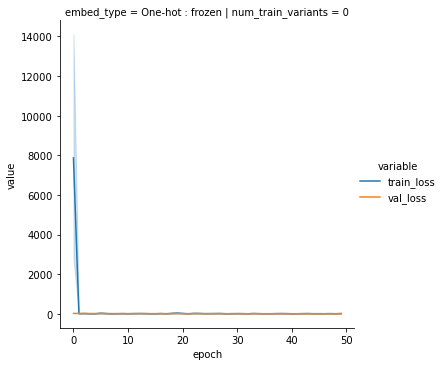

In [7]:
with open("../data/scratch/model_stats/LinearRosettaEnergyPrediction_0_0.pkl", "rb") as inp:
    retd = pickle.load(inp)
    
# plot loss curves if we want to see them
mdf = retd["metrics"]
mdf["num_train_variants"] = retd["num_train_variants"]
embed_type = model_embed_type(retd["embed_ncomp"], retd["embed_freeze"])
mdf["embed_type"] = embed_type
            
g = sns.relplot(x="epoch", y="value", col="num_train_variants", row="embed_type", 
                hue='variable', data=mdf, kind="line")  

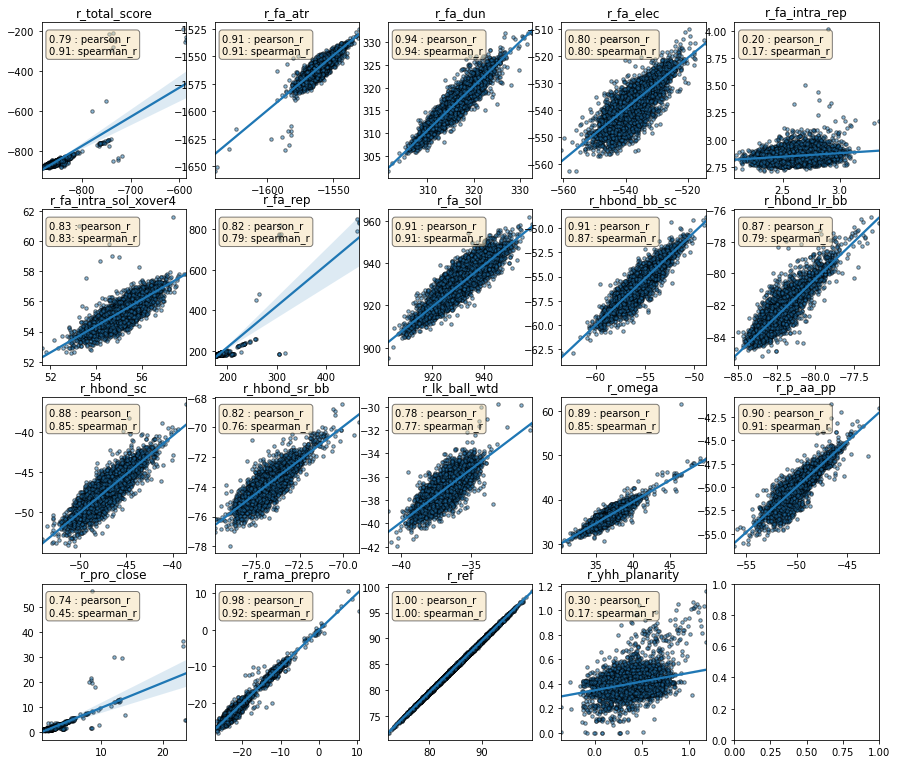

In [8]:
plot_columns(column_names_to_plot=relaxed_column_names, 
             all_columns_names=column_names,
             predictions=retd["predictions"],
             values=retd["values"])

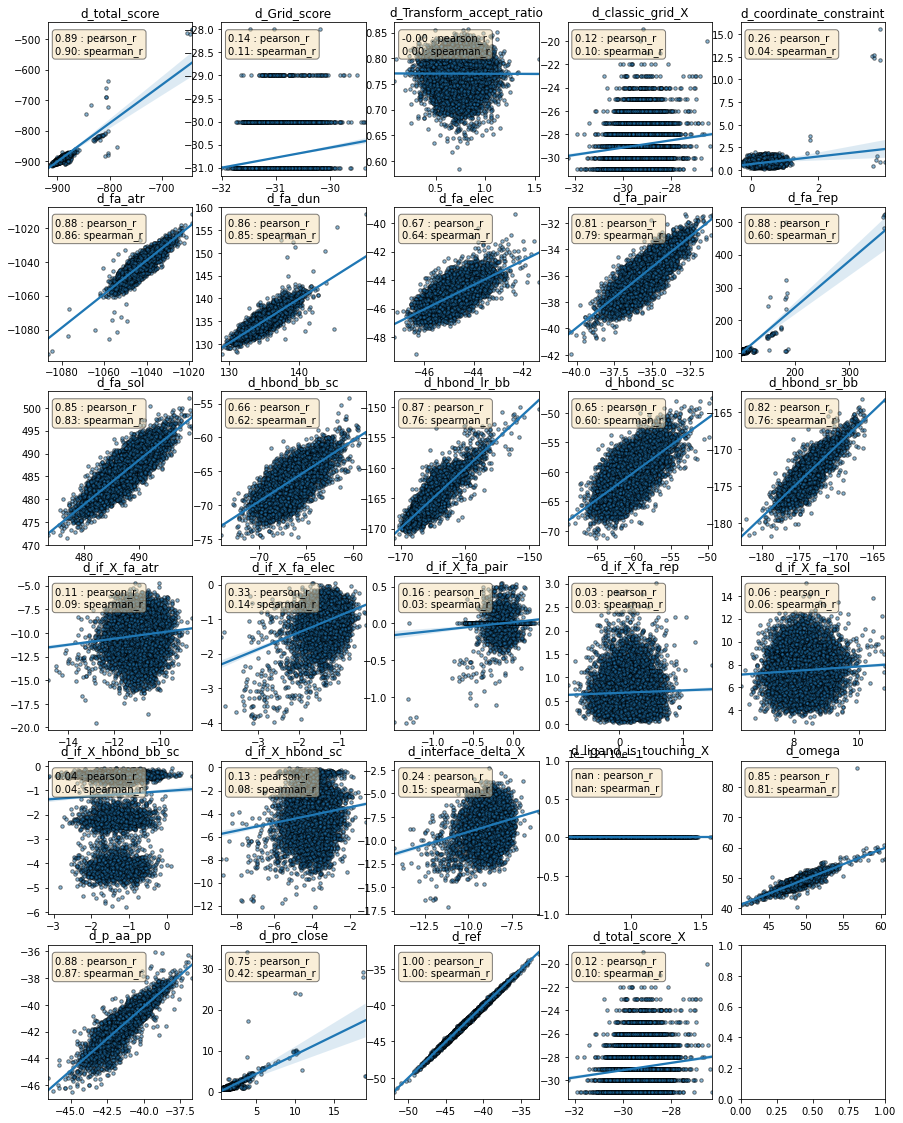

In [9]:
plot_columns(column_names_to_plot=docking_column_names, 
    all_columns_names=column_names,
    predictions=retd["predictions"],
    values=retd["values"])

## CNN

`kernel_size = 5`, `embedding = 8 (PCA comps)`, `trainable embedding`

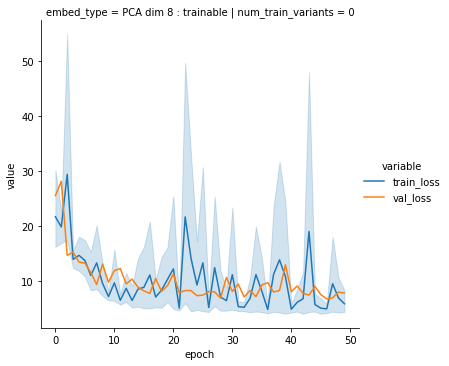

In [10]:
with open("../data/scratch/model_stats/CNNRosettaEnergyPrediction_0_8_trained.pkl", "rb") as inp:
    retd = pickle.load(inp)
    
# plot loss curves if we want to see them
mdf = retd["metrics"]
mdf["num_train_variants"] = retd["num_train_variants"]
embed_type = model_embed_type(retd["embed_ncomp"], retd["embed_freeze"])
mdf["embed_type"] = embed_type
            
g = sns.relplot(x="epoch", y="value", col="num_train_variants", row="embed_type", 
                hue='variable', data=mdf, kind="line")  

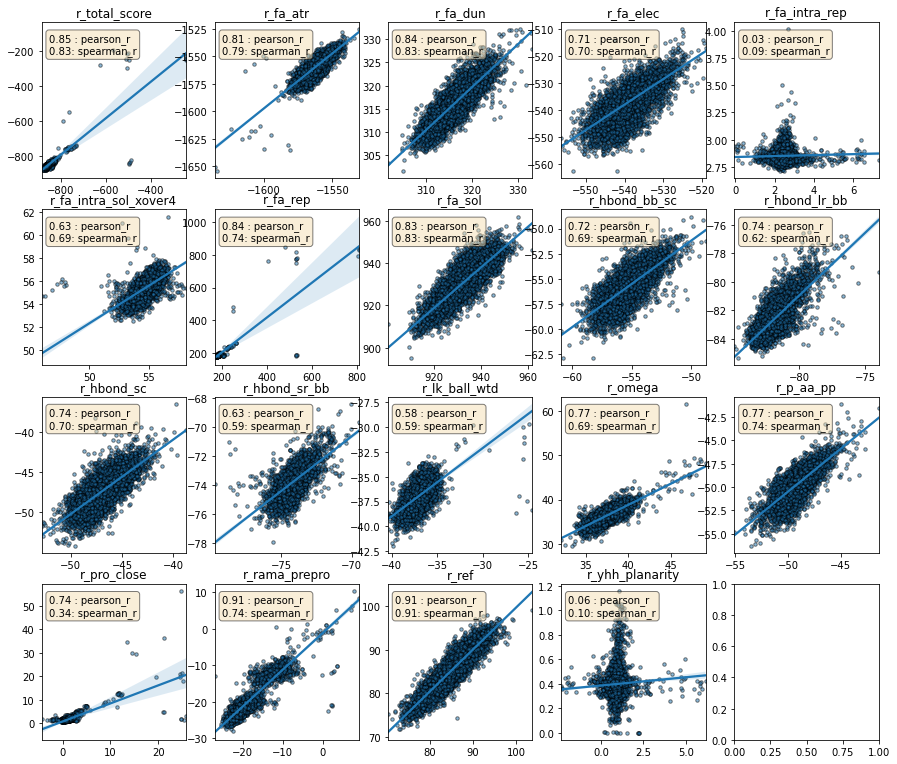

In [11]:
plot_columns(column_names_to_plot=relaxed_column_names, 
             all_columns_names=column_names,
             predictions=retd["predictions"],
             values=retd["values"])

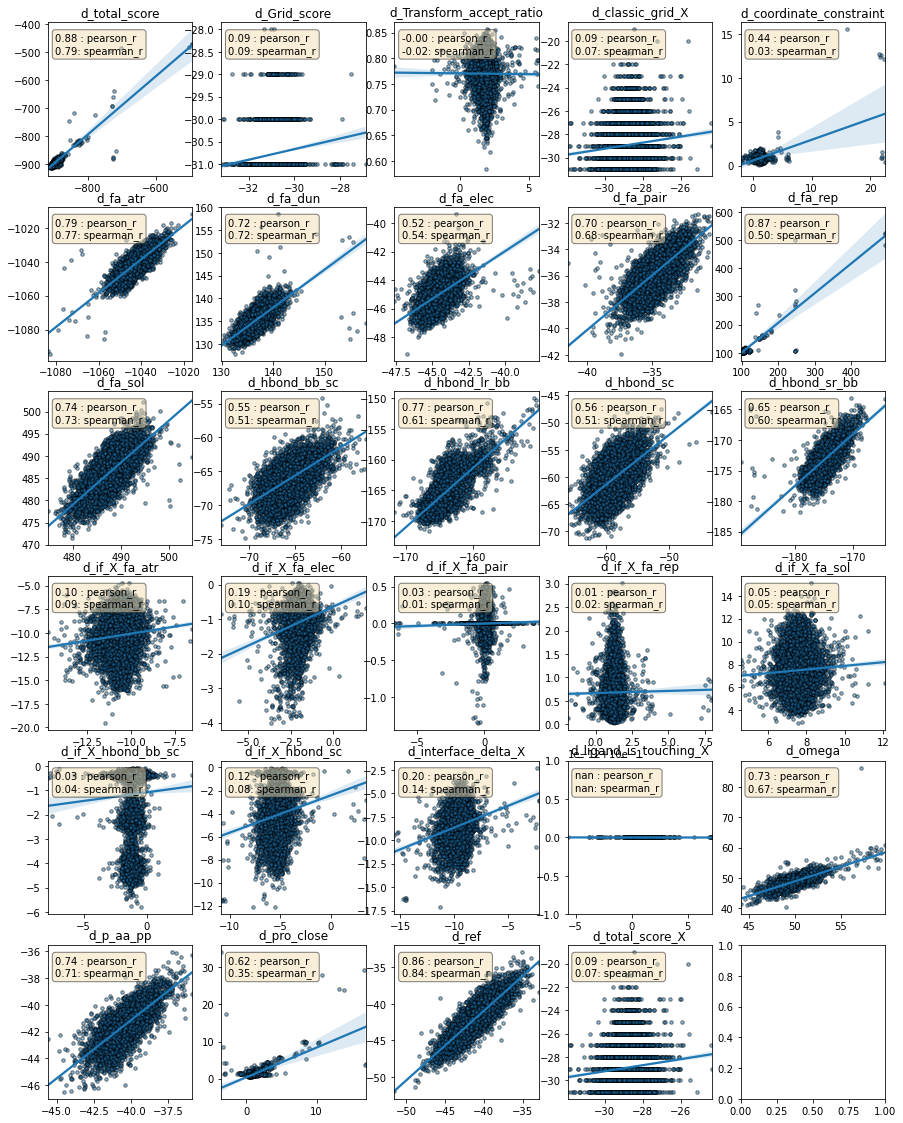

In [12]:
plot_columns(column_names_to_plot=docking_column_names, 
    all_columns_names=column_names,
    predictions=retd["predictions"],
    values=retd["values"])